## ------------------------------------------------------------------------------------------------------------

## Programming Assignment 1 (Deep Learning From Scratch)
In this assignment we implement a Deep Neural Network

Implement from scratch (hence not using NN libraries such as tensorow,
keras, pytorch) a Neural Network that is able to approximate a function of
two variables f(x, y). The network will have at least two hidden layers and it
is trained using the backpropagation algorithm. The test case we consider is
f(x, y) = x · y (we can say that we teach the network to multiply two numbers).

As training data for the algorithm construct a matrix of input output triplets
of the function f(x, y) = x · y. When x, y ∈ [0, 1] the matrix would contain
training triplets of the form [xi
, yj , xi
· yj ], where xi and yj are random values
in [0, 1].

Try dierent activation functions and nd which one performs best with your
network. For validation accuracy calculate the root mean square error.

Add visualization of the RMSE over training epochs, and perform simple
tests to check accuracy.

## ------------------------------------------------------------------------------------------------------------

In [160]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [161]:
class Layer:
    def forward(self, inner):
        raise NotImplementedError

    def backward(self, grad_ooutput):
        raise NotImplementedError


In [162]:
class Dense(Layer):
    def __init__(self, input_size, output_size, learning_rate=0.1):
        self.W = np.random.randn(input_size, output_size) * 0.1;
        self.b = np.zeros((1, output_size))
        self.lr = learning_rate

    def forward(self, input):
        self.input = input
        return input @ self.W + self.b

    def backward(self, grad_output):
        grad_W = self.input.T @ grad_output
        grad_b = np.sum(grad_output, axis=0, keepdims=True)
        grad_input = grad_output @ self.W.T

        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b

        return grad_input

In [163]:
class ReLU(Layer):
    def forward(self, input):
        self.input = input
        return np.maximum(0, input)

    def backward(self, grad_output):
        grad_input = grad_output * (self.input > 0).astype(float)
        return grad_input


In [164]:
class Sigmoid(Layer):
    def forward(self, input):
        self.output = 1 / (1 + np.exp(-input))
        return self.output

    def backward(self, grad_output):
        grad_input = grad_output * self.output * (1 - self.output)
        return grad_input


In [165]:
class Tanh(Layer):
    def forward(self, input):
        self.output = np.tanh(input)
        return self.output

    def backward(self, grad_output):
        grad_input = grad_output * (1 - self.output ** 2)
        return grad_input


## Testing: ReLu, Sigmoid, Tanh

In [166]:
X = np.array([[-1, 0, 1], [2, -3, 0.5]])

relu = ReLU()
sigmoid = Sigmoid()
tanh = Tanh()

print("ReLU forward:\n", relu.forward(X))
print("Sigmoid forward:\n", sigmoid.forward(X))
print("Tanh forward:\n", tanh.forward(X))

grad = np.ones_like(X)
print("ReLU backward:\n", relu.backward(grad))
print("Sigmoid backward:\n", sigmoid.backward(grad))
print("Tanh backward:\n", tanh.backward(grad))


ReLU forward:
 [[0.  0.  1. ]
 [2.  0.  0.5]]
Sigmoid forward:
 [[0.26894142 0.5        0.73105858]
 [0.88079708 0.04742587 0.62245933]]
Tanh forward:
 [[-0.76159416  0.          0.76159416]
 [ 0.96402758 -0.99505475  0.46211716]]
ReLU backward:
 [[0. 0. 1.]
 [1. 0. 1.]]
Sigmoid backward:
 [[0.19661193 0.25       0.19661193]
 [0.10499359 0.04517666 0.23500371]]
Tanh backward:
 [[0.41997434 1.         0.41997434]
 [0.07065082 0.00986604 0.78644773]]


In [167]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mse_grad(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.shape[0]


In [168]:
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, grad_output):
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def train(self, X, y, epochs=1000):
        history = []
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Compute loss
            error = rmse(y, y_pred)
            history.append(error)
            
            # Backward pass
            grad_loss = mse_grad(y, y_pred)
            self.backward(grad_loss)

            # Logging
            if epoch % 100 == 0:
                idx = 0  # just look at the first sample
                print(
                f"Epoch {epoch}, RMSE: {error:.6f}, " 
                f"y_true: {y[idx, 0]:.6f}, y_pred: {y_pred[idx, 0]:.6f}"
                )
                

        return history


In [169]:
def generate_data(n_samples=2000):
    x = np.random.rand(n_samples, 1)
    y = np.random.rand(n_samples, 1)
    z = x * y
    X = np.hstack([x, y])
    return X, z


## --------------------------------------------------------------------------------------------------

##  Training for ReLU:

In [170]:
X, y = generate_data()

layers = [
    Dense(2, 16),
    ReLU(),
    Dense(16, 16),
    ReLU(),
    Dense(16, 1)  # linear output
]

nn1 = NeuralNetwork(layers)
history1 = nn1.train(X, y, epochs=2000)


Epoch 0, RMSE: 0.332344, y_true: 0.098019, y_pred: -0.000630
Epoch 100, RMSE: 0.206320, y_true: 0.098019, y_pred: 0.233741
Epoch 200, RMSE: 0.164090, y_true: 0.098019, y_pred: 0.194974
Epoch 300, RMSE: 0.089793, y_true: 0.098019, y_pred: 0.104981
Epoch 400, RMSE: 0.066840, y_true: 0.098019, y_pred: 0.054378
Epoch 500, RMSE: 0.051428, y_true: 0.098019, y_pred: 0.046872
Epoch 600, RMSE: 0.042470, y_true: 0.098019, y_pred: 0.058057
Epoch 700, RMSE: 0.038262, y_true: 0.098019, y_pred: 0.061051
Epoch 800, RMSE: 0.036122, y_true: 0.098019, y_pred: 0.061672
Epoch 900, RMSE: 0.034665, y_true: 0.098019, y_pred: 0.062809
Epoch 1000, RMSE: 0.033364, y_true: 0.098019, y_pred: 0.064017
Epoch 1100, RMSE: 0.032173, y_true: 0.098019, y_pred: 0.066597
Epoch 1200, RMSE: 0.031016, y_true: 0.098019, y_pred: 0.068915
Epoch 1300, RMSE: 0.029900, y_true: 0.098019, y_pred: 0.070887
Epoch 1400, RMSE: 0.028810, y_true: 0.098019, y_pred: 0.072696
Epoch 1500, RMSE: 0.027726, y_true: 0.098019, y_pred: 0.074485
Epo

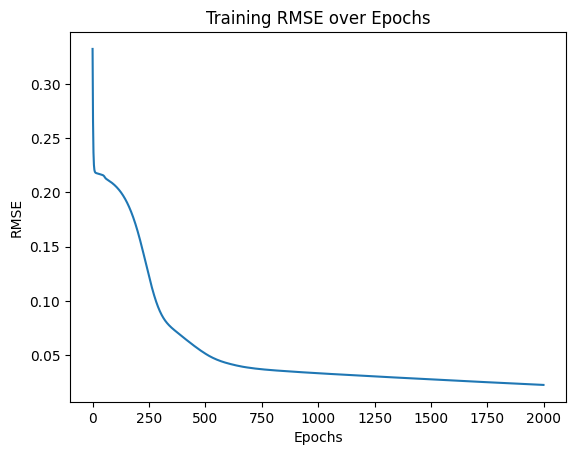

In [171]:
plt.plot(history1)
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.title("Training RMSE over Epochs")
plt.show()


## --------------------------------------------------------------------------------------------------

## Tests to check accuracy for ReLU :

In [172]:
# Generate test data
X_test, y_test = generate_data(n_samples=5)  # small number for quick testing
y_pred_test = nn1.forward(X_test)

# Print predictions vs actual
print("Test Inputs:\n", X_test)
print("Actual Outputs:\n", y_test)
print("Predicted Outputs:\n", y_pred_test)

# Compute RMSE on test set
test_error = rmse(y_test, y_pred_test)
print(f"Test RMSE: {test_error:.6f}")


Test Inputs:
 [[0.87803351 0.04406586]
 [0.55787368 0.18527685]
 [0.95979102 0.54127011]
 [0.04869485 0.64557218]
 [0.09800768 0.04558516]]
Actual Outputs:
 [[0.0386913 ]
 [0.10336108]
 [0.51950619]
 [0.03143604]
 [0.0044677 ]]
Predicted Outputs:
 [[0.1015276 ]
 [0.09030931]
 [0.52299872]
 [0.04714773]
 [0.01709246]]
Test RMSE: 0.030124


In [173]:
test_points = np.array([
    [0.2, 0.4],
    [0.5, 0.5],
    [0.9, 0.1]
])

predictions = nn1.forward(test_points)
for p, pred in zip(test_points, predictions):
    print(f"x={p[0]:.2f}, y={p[1]:.2f}, true={p[0]*p[1]:.3f}, pred={pred[0]:.3f}")


x=0.20, y=0.40, true=0.080, pred=0.062
x=0.50, y=0.50, true=0.250, pred=0.226
x=0.90, y=0.10, true=0.090, pred=0.133


## --------------------------------------------------------------------------------------------------

##  Training for Sigmoid:

In [174]:
X, y = generate_data()

layers = [
    Dense(2, 16),
    Sigmoid(),
    Dense(16, 16),
    Sigmoid(),
    Dense(16, 1)  # linear output
]

nn2 = NeuralNetwork(layers)
history2 = nn2.train(X, y, epochs=2000)

Epoch 0, RMSE: 0.502529, y_true: 0.937119, y_pred: -0.210739
Epoch 100, RMSE: 0.215609, y_true: 0.937119, y_pred: 0.243596
Epoch 200, RMSE: 0.215504, y_true: 0.937119, y_pred: 0.243858
Epoch 300, RMSE: 0.215391, y_true: 0.937119, y_pred: 0.244142
Epoch 400, RMSE: 0.215267, y_true: 0.937119, y_pred: 0.244451
Epoch 500, RMSE: 0.215132, y_true: 0.937119, y_pred: 0.244790
Epoch 600, RMSE: 0.214983, y_true: 0.937119, y_pred: 0.245164
Epoch 700, RMSE: 0.214816, y_true: 0.937119, y_pred: 0.245581
Epoch 800, RMSE: 0.214630, y_true: 0.937119, y_pred: 0.246048
Epoch 900, RMSE: 0.214420, y_true: 0.937119, y_pred: 0.246575
Epoch 1000, RMSE: 0.214182, y_true: 0.937119, y_pred: 0.247172
Epoch 1100, RMSE: 0.213910, y_true: 0.937119, y_pred: 0.247853
Epoch 1200, RMSE: 0.213598, y_true: 0.937119, y_pred: 0.248636
Epoch 1300, RMSE: 0.213238, y_true: 0.937119, y_pred: 0.249539
Epoch 1400, RMSE: 0.212820, y_true: 0.937119, y_pred: 0.250589
Epoch 1500, RMSE: 0.212332, y_true: 0.937119, y_pred: 0.251816
Epo

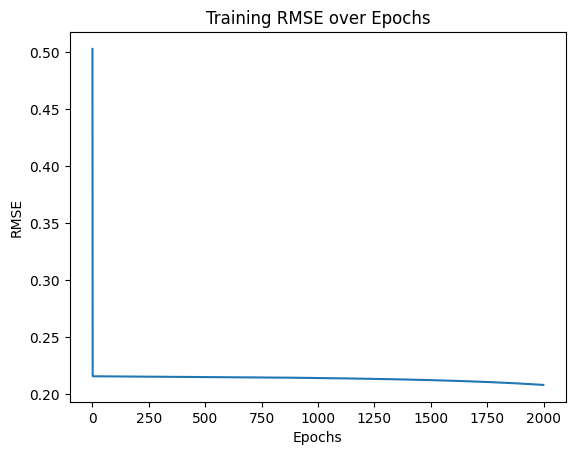

In [175]:
plt.plot(history2)
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.title("Training RMSE over Epochs")
plt.show()

## --------------------------------------------------------------------------------------------------

## Tests to check accuracy for Sigmoid :

In [176]:
# Generate test data
X_test, y_test = generate_data(n_samples=5)  # small number for quick testing
y_pred_test = nn2.forward(X_test)

# Print predictions vs actual
print("Test Inputs:\n", X_test)
print("Actual Outputs:\n", y_test)
print("Predicted Outputs:\n", y_pred_test)

# Compute RMSE on test set
test_error = rmse(y_test, y_pred_test)
print(f"Test RMSE: {test_error:.6f}")


Test Inputs:
 [[0.1430814  0.47175631]
 [0.85788919 0.49581947]
 [0.3088609  0.73223791]
 [0.6588554  0.08777291]
 [0.56644369 0.66818066]]
Actual Outputs:
 [[0.06749955]
 [0.42535816]
 [0.22615966]
 [0.05782966]
 [0.37848672]]
Predicted Outputs:
 [[0.23194223]
 [0.25317953]
 [0.24042308]
 [0.24177404]
 [0.24707412]]
Test RMSE: 0.146966


## --------------------------------------------------------------------------------------------------

##  Training for Tanh:

In [177]:
X, y = generate_data()

layers = [
    Dense(2, 16),
    Tanh(),
    Dense(16, 16),
    Tanh(),
    Dense(16, 1)  # linear output
]

nn3 = NeuralNetwork(layers)
history3 = nn3.train(X, y, epochs=2000)

Epoch 0, RMSE: 0.321192, y_true: 0.704693, y_pred: 0.014589
Epoch 100, RMSE: 0.184964, y_true: 0.704693, y_pred: 0.310850
Epoch 200, RMSE: 0.119648, y_true: 0.704693, y_pred: 0.444627
Epoch 300, RMSE: 0.087967, y_true: 0.704693, y_pred: 0.552187
Epoch 400, RMSE: 0.086257, y_true: 0.704693, y_pred: 0.574167
Epoch 500, RMSE: 0.085939, y_true: 0.704693, y_pred: 0.577470
Epoch 600, RMSE: 0.085674, y_true: 0.704693, y_pred: 0.578508
Epoch 700, RMSE: 0.085432, y_true: 0.704693, y_pred: 0.579234
Epoch 800, RMSE: 0.085207, y_true: 0.704693, y_pred: 0.579877
Epoch 900, RMSE: 0.084999, y_true: 0.704693, y_pred: 0.580474
Epoch 1000, RMSE: 0.084806, y_true: 0.704693, y_pred: 0.581033
Epoch 1100, RMSE: 0.084625, y_true: 0.704693, y_pred: 0.581557
Epoch 1200, RMSE: 0.084456, y_true: 0.704693, y_pred: 0.582052
Epoch 1300, RMSE: 0.084298, y_true: 0.704693, y_pred: 0.582520
Epoch 1400, RMSE: 0.084148, y_true: 0.704693, y_pred: 0.582964
Epoch 1500, RMSE: 0.084007, y_true: 0.704693, y_pred: 0.583385
Epoc

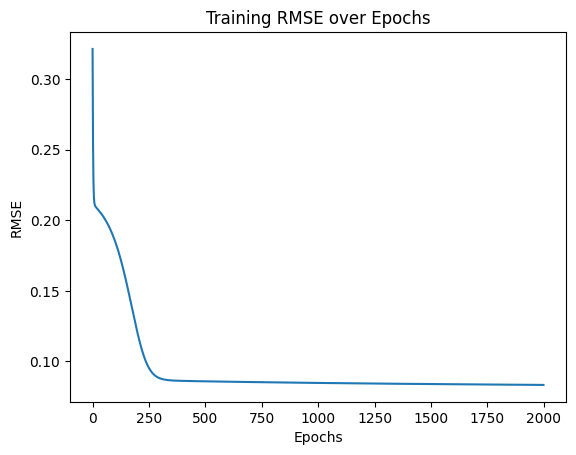

In [178]:
plt.plot(history3)
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.title("Training RMSE over Epochs")
plt.show()

## --------------------------------------------------------------------------------------------------

## Tests to check accuracy for Tanh :

In [179]:
# Generate test data
X_test, y_test = generate_data(n_samples=5)  # small number for quick testing
y_pred_test = nn3.forward(X_test)

# Print predictions vs actual
print("Test Inputs:\n", X_test)
print("Actual Outputs:\n", y_test)
print("Predicted Outputs:\n", y_pred_test)

# Compute RMSE on test set
test_error = rmse(y_test, y_pred_test)
print(f"Test RMSE: {test_error:.6f}")


Test Inputs:
 [[0.55868144 0.18590171]
 [0.84997577 0.00479982]
 [0.99599105 0.50911369]
 [0.50815731 0.55551867]
 [0.34520403 0.82493848]]
Actual Outputs:
 [[0.10385984]
 [0.00407973]
 [0.50707268]
 [0.28229087]
 [0.28477209]]
Predicted Outputs:
 [[0.12007708]
 [0.17515297]
 [0.49895353]
 [0.28065117]
 [0.33294966]]
Test RMSE: 0.079898


## --------------------------------------------------------------------------------------------------

## Activation Functions and Learning Speed

1. **ReLU** – learns the fastest.  
2. **Tanh** – the second fastest.  
3. **Sigmoid** – the slowest among the three.
